# **Homework 2**

**Name:** Ankit BhagwatiPrasad Dhandharia

**CWID:** 20033031

### **Connecting Google Drive To Import Dataset**

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Importing Required Libraries**

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## **Part 1: Loading dataset & Ploting Chart**

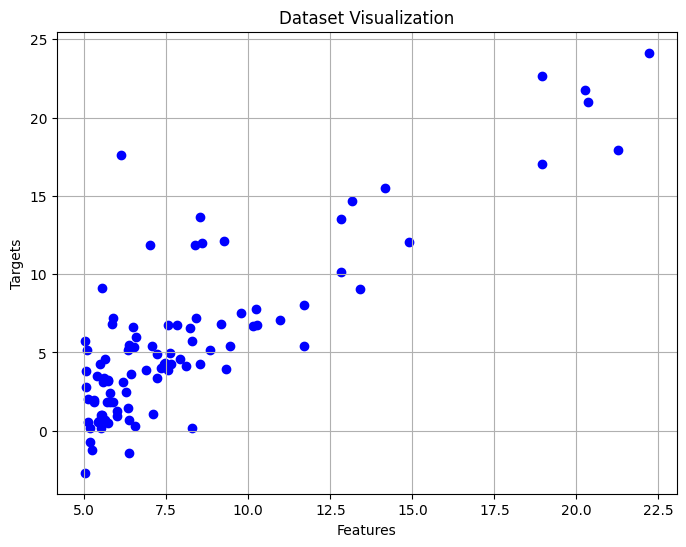

In [18]:
dataset = np.loadtxt('drive/MyDrive/data2.txt', delimiter=',')
features = dataset[:, 0]    # First column
targets = dataset[:, 1]     # Second column

# Create initial visualization of data
plt.figure(figsize=(8, 6))
plt.scatter(features, targets, color='blue')
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('Dataset Visualization')
plt.grid()
plt.show()

## **Part 2: Normal Equation**

Normal Equation Results:
Bias term (w0) = -3.8957808783118772
Slope (w1) = 1.1930336441895957


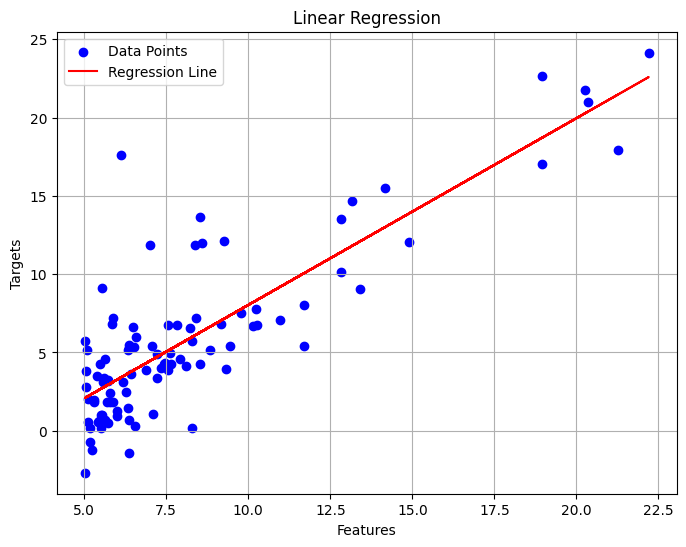

In [19]:
# Add bias for w0 in y = w0 + w1*x as indicated in homework
bias_column = np.ones(len(features))
X_matrix = np.column_stack((bias_column, features))

# Calculate weights using Normal Equation
matrix_transpose = X_matrix.T
temp_matrix = np.dot(matrix_transpose, X_matrix)
inverse_matrix = np.linalg.inv(temp_matrix)
weights = np.dot(np.dot(inverse_matrix, matrix_transpose), targets)

print("Normal Equation Results:")
print("Bias term (w0) =", weights[0])
print("Slope (w1) =", weights[1])

# Plot regression line from Normal Equation
plt.figure(figsize=(8, 6))
plt.scatter(features, targets, color='blue', label='Data Points')
plt.plot(features, weights[0] + weights[1]*features, color='red', label='Regression Line')
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('Linear Regression')
plt.legend()
plt.grid()
plt.show()

## **Part 3: Gradient Descent**

### **3.a: Split dataset into 80% for training and 20% for testing.**

In [20]:
# Reshape features for sklearn
features_reshaped = features.reshape(-1, 1)
train_features, test_features, train_targets, test_targets = train_test_split(features_reshaped, targets, test_size=0.2, random_state=42)
train_matrix = np.column_stack((np.ones(len(train_features)), train_features)) # Add bias to training
test_matrix = np.column_stack((np.ones(len(test_features)), test_features)) # Add bias to testing

### **3.b: Batch Gradient Descent (BGD)**

BGD Results:
Final bias (w0) = -0.6586850496681685
Final slope (w1) = 0.8705326216954683


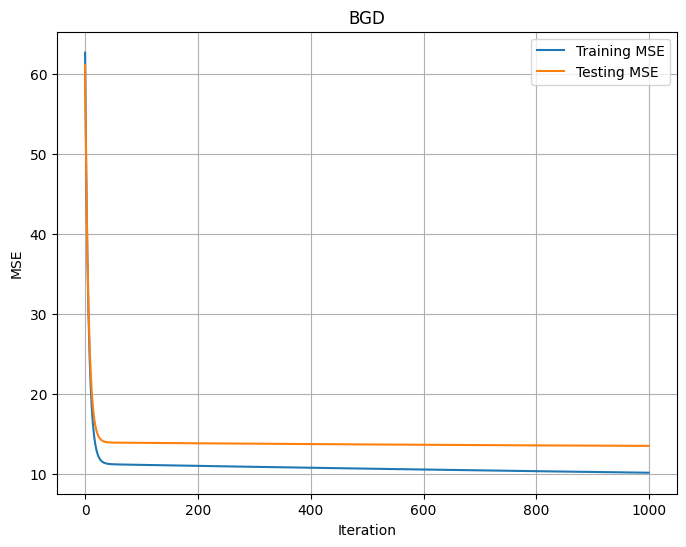

In [21]:
model_weights = np.zeros(2)  # w0 and w1 initialized to zero
learning_rate = 0.001 # Step size for gradient descent
max_iterations = 1000

# Lists to store Mean Squared Error (MSE)
training_errors = []
testing_errors = []

# Training Batch Gradient Descent
for iteration in range(max_iterations):
    train_predictions = np.dot(train_matrix, model_weights)
    prediction_errors = train_predictions - train_targets
    model_weights = model_weights - learning_rate * (np.dot(train_matrix.T, prediction_errors) / len(train_features)) # Update weights
    # Calculate MSE for both sets
    train_mse = np.mean((train_predictions - train_targets)**2)
    test_predictions = np.dot(test_matrix, model_weights)
    test_mse = np.mean((test_predictions - test_targets)**2)
    training_errors.append(train_mse)
    testing_errors.append(test_mse)

print("BGD Results:")
print("Final bias (w0) =", model_weights[0])
print("Final slope (w1) =", model_weights[1])

# Plot error convergence for BGD
plt.figure(figsize=(8, 6))
plt.plot(training_errors, label='Training MSE')
plt.plot(testing_errors, label='Testing MSE')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('BGD')
plt.legend()
plt.grid()
plt.show()